# Measuring $H_0$ with gravitational wave sirens

The function of this program is to obtain a distribution of the Hubble constant $H_0$ from the posterior LIGO/Virgo samples of GW170817. The primary plot to produce here is a two-dimensional posterior distribution of $H_0$ and the inclination angle $\iota$, showing the median and the 68\% credible interval and comparing the obtained values to values from the Planck 2018 and the SH0ES models.

In [1]:
import h5py
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from scipy.stats import norm
import matplotlib.pyplot as plt
import corner
import emcee

# [Data Extraction and Constants](#data-extraction-and-constants)

The data is extracted from `/data/GW170817_GWTC-1.hdf5` into the variable `df`. A number of `print()` functions have been included as comments, to allow the user to view the nature of the dataset should they wish to do so. The data from `df` contains the values of the luminosity distances $d_L$ and of the (cosines of the) inclination angles $\cos(\iota)$. These values are loaded into the variables `d_l` and `cos_iota` respectively.

Constant variables $c$ and $z$ are also set from sources __[NED](https://ned.ipac.caltech.edu/byname?objname=ngc+4993&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1)__ and __[NIST](https://physics.nist.gov/cgi-bin/cuu/Value?c)__ respectively.

Finally, we also set the $H_0$ values from the __[Planck 2018](https://arxiv.org/abs/1807.06209v4)__ and __[SH0ES](https://doi.org/10.48550/arXiv.2112.04510)__ models for comparison later.

In [2]:
#importing file
f = h5py.File("../data/GW170817_GWTC-1.hdf5", "r")

#check file contents
print(list(f.keys()))

# extract and check type of IMRPhenomPv2NRT_highSpin_posterior
post = f['IMRPhenomPv2NRT_highSpin_posterior']
print(type(f['IMRPhenomPv2NRT_highSpin_posterior']))

#create pandas dataframe to visualize data
df = pd.read_hdf('../data/GW170817_GWTC-1.hdf5', key='IMRPhenomPv2NRT_highSpin_posterior')
print(df.head(5))

['IMRPhenomPv2NRT_highSpin_posterior', 'IMRPhenomPv2NRT_highSpin_prior', 'IMRPhenomPv2NRT_lowSpin_posterior', 'IMRPhenomPv2NRT_lowSpin_prior']
<class 'h5py._hl.dataset.Dataset'>
   costheta_jn  luminosity_distance_Mpc  right_ascension  declination  \
0    -0.994916                45.252574          3.44616    -0.408084   
1    -0.986352                45.872286          3.44616    -0.408084   
2    -0.805300                37.419041          3.44616    -0.408084   
3    -0.994375                47.550072          3.44616    -0.408084   
4    -0.972559                46.396693          3.44616    -0.408084   

   m1_detector_frame_Msun  m2_detector_frame_Msun     lambda1      lambda2  \
0                1.822412                1.054311  445.419935   799.248200   
1                1.691038                1.128312  255.135494   251.741954   
2                1.712651                1.115415  244.847341  1240.723296   
3                1.686980                1.130922  243.045010   736.271

In [3]:
# to replicate the 2D histogram of H_0 and cos(iota) we need the luminosity distance(d_l) and cos(iota) samples
d_l = df['luminosity_distance_Mpc']
cos_iota = df['costheta_jn']

z = 0.009877                # redshift from https://ned.ipac.caltech.edu/byname?objname=ngc+4993&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1
z_uncert = 1.67e-5 
c = 299792.458              # speed of light in km/s from https://physics.nist.gov/cgi-bin/cuu/Value?c
planck_mean = 67.4          #https://arxiv.org/abs/1807.06209v4
planck_sigma = 0.5
shoes_mean = 73.30          # https://doi.org/10.48550/arXiv.2112.04510
shoes_sigma = 1.04
sigma_pec = 250             # km/s, typical peculiar-velocity correction Gaussian spread, as stated in project proposal
np.random.seed(123456)      # for reproducibility 

### Redshift Uncertainty

The total redshift uncertainty combines measurement error and peculiar velocity. Following the project proposal, the peculiar velocity is modelled as a velocity dispersion $ \sigma_{\mathrm{pec}} \approx 250\,\mathrm{km\,s^{-1}} $, giving a redshift uncertainty $ \sigma_{\mathrm{pec}}/c $.

Assuming measurement error and peculiar velocity are independent, they are added in quadrature:

$
\sigma_z = \sqrt{\sigma_{z,\text{meas}}^2 + \left(\frac{\sigma_{\mathrm{pec}}}{c}\right)^2}
$

This will later be employed to smear out the likelihood grid accordingly.

In [4]:
sigma_z = np.sqrt(z_uncert**2 + (sigma_pec / c)**2)     # following z=v/c, and using the z uncertainty

# [Visualizing Data](#Visualizing-Data)

As a preliminary measure, we would like to visualize the data that we are working with. We convert the luminosity distance values $d_L$ to Hubble constant values using the low redshift approximation formula

$d_L = \dfrac{c}{H_0}z$.

 A 2D histogram of $H_0$ and $\cos(\iota)$ is then produced with the data we have extracted and converted.

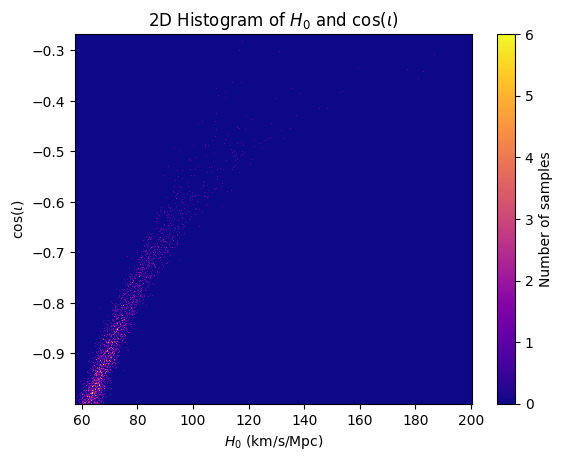

In [5]:
# low redshift approximation: d_L = (c/H_0) * z
H_0 = (c * z) / d_l

#Visualize the 2D distribution of H_0 and cos(iota)
plt.hist2d(H_0, cos_iota, bins=500, cmap = 'plasma', range=None, density=False, weights=None, cmin=None, cmax=None, data=None)
plt.colorbar(label='Number of samples')
plt.xlabel(r'$H_0$ (km/s/Mpc)')
plt.ylabel(r'cos($\iota$)')
plt.title(r'2D Histogram of $H_0$ and cos($\iota$)')
plt.show()

# [Likelihood](#likelihood)

In order to implement an MCMC chain, we need to obtain the likelihood distribution of our data. This will be a two dimensional distribution, with variable $H_0$ and $\cos(\iota)$, using a Kernel Density Estimate (KDE) of the data. To accomodate the two dimensional, we use meshgrids to evaluate the KDE on a grid of points.

To transform the data from $(d_L, \cos(\iota))$ to $(H_0, \cos(\iota))$ we need to make use of the jacobian $J$, given by

$J = |\frac{\partial d_L}{\partial H_0}| = |-\frac{cz}{H_0^2}|$,

where we have used the low redshift approximation shown in [Visualizing Data](#visualizing-data).

The function `likelihood_function()` takes KDE bandwidth values as an argument, and builds the likelihood distribution accordingly. For our final MCMC chain, this function is only implemented once, as we use the same bandwidth across all MCMC chain iterations. However, before implementing the MCMC algorithm, we would like to check the KDE bandwidth sensitivity. In this goal, the likelihood is plotted for different bandwidths.

The function `log_likelihood()` takes values of $H_0$ and $\cos(\iota)$ and the likelihood grid as arguments. It finds the position of the $H_0$ and $\cos(\iota)$ values on the likelihood grid (more precisely it find the closest point to the values; the grid is discrete and so exact equality will not usually occur), and returns the $log()$ of the corresponding likelihood. As a precaution, the function is also equipped to handle invalid values and return $-\infty$ should this occur.

In [6]:
# meshgrids used for evaluating the kde on a grid of points
# cos iota from -1 to 1, H_0 from min to max values of the samples

H_0_grid, cos_iota_grid = np.meshgrid(np.linspace(min(H_0), max(H_0), 100), np.linspace(-1, 1, 100))

# low redshift approximation: d_L = (c/H_0) * z
d_l_grid = (c * z) / H_0_grid

In [7]:
def likelihood_function(bandwidth):
    """ 
    Compute the likelihood of the data given the model parameters (H_0, cos(iota)) using a kernel density estimate (kde) of the data.
    Makes use of the low redshift approximation to relate the luminosity distance to H_0 and the redshift.
    """ 
    
    data_l_d_cos_iota = np.vstack((d_l,cos_iota)) # needed because kde for 2D takes a 2D array of shape (# dims, # data)

    # kde model 
    kde = gaussian_kde(data_l_d_cos_iota,bw_method=bandwidth)

    # apply kde to the grid points
    # we need to ravel (flatten) the grid points and stack them into a 2D array of shape (# dims, # grid points) for the kde
    kde_values = kde(np.vstack([d_l_grid.ravel(), cos_iota_grid.ravel()]))

    # define jacobian for the transformation from (d_L, cos(iota)) to (H_0, cos(iota))
    J = (c * z) / (H_0_grid**2)

    # Get distance uncertainty from peculiar velocity correction and z uncertainty
    sigma_dL = (c / H_0_grid) * sigma_z

    # Predicted distance from Hubble law
    dL_model = (c * z) / H_0_grid

    # Gaussian weight from redshift uncertainty
    z_weight = norm.pdf(d_l_grid, loc=dL_model, scale=sigma_dL)

     # need to reshape the kde values back to the shape of the grid and multiply by the jacobian to get the likelihood in terms of (H_0, cos(iota)). include smearing from peculiar velocity correction
    likelihood = kde_values.reshape(H_0_grid.shape) * J * z_weight

    return likelihood

In [8]:
kde_bandwidths = [0.1,1,10]
likelihoods = [likelihood_function(bw) for bw in kde_bandwidths]

In [9]:
def log_likelihood(theta, likelihood=likelihoods[0]):
    H0, cos_iota_val = theta

    # Extract grid axes
    H0_values = H_0_grid[0, :]
    cos_iota_values = cos_iota_grid[:, 0]

    # Reject out-of-bounds
    if H0 < H0_values.min() or H0 > H0_values.max():
        return -np.inf
    if cos_iota_val < cos_iota_values.min() or cos_iota_val > cos_iota_values.max():
        return -np.inf

    # Find nearest indices
    i = np.abs(cos_iota_values - cos_iota_val).argmin()
    j = np.abs(H0_values - H0).argmin()


    # Extract likelihood value
    like = likelihood[i, j]

    # Handle invalid values
    if like <= 0 or not np.isfinite(like):
        return -np.inf

    return np.log(like)

<Figure size 600x500 with 0 Axes>

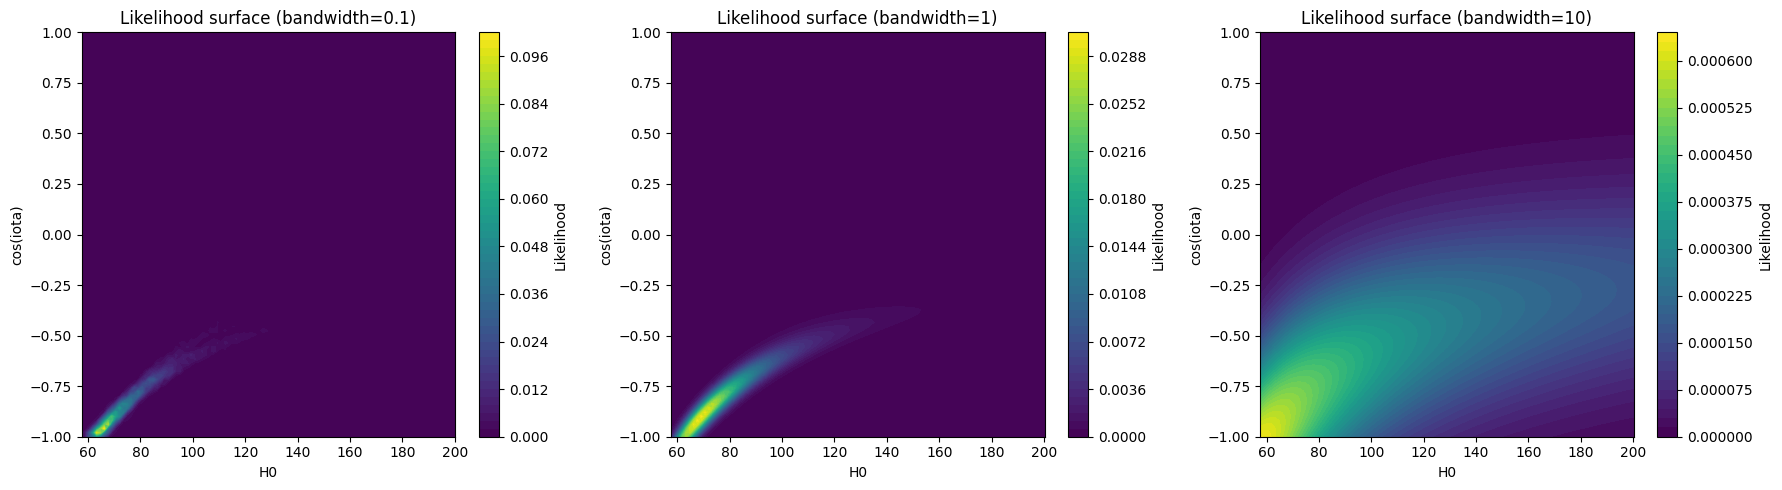

In [10]:
plt.figure(figsize=(6,5))
fig,ax = plt.subplots(1,len(kde_bandwidths), figsize=(18,5))
for i, bw in enumerate(kde_bandwidths):
    ax[i].contourf(H_0_grid, cos_iota_grid, likelihoods[i], levels=50)
    ax[i].set_xlabel("H0")
    ax[i].set_ylabel("cos(iota)")
    ax[i].set_title(f"Likelihood surface (bandwidth={bw})")
    fig.colorbar(ax[i].collections[0], ax=ax[i], label="Likelihood")
plt.tight_layout()
plt.show()
# plt.contourf(H_0_grid, cos_iota_grid, likelihood, levels=50)
# plt.xlabel("H0")
# plt.ylabel("cos(iota)")
# plt.title("Likelihood surface")
# plt.colorbar(label="Likelihood")
# plt.show()

# [Metro-Hastings Algorithm](#metro-hastings-algorithm)

We have decided to use the flat-in-log prior $\dfrac{1}{H_0}$ and flat prior on $\cos(\iota)$ following the work done by __[B. P. Abbot et al.](https://doi.org/10.1038/nature24471)__. This has been implemented as it's own external function `log_prior()` so that a change of prior is easily actualisable by the user.

The two dimensional Metro-Hastings algorithm is implemented in the function `sampler_2D()`. The function takes as arguments the number of samples, initial values, proposal width, and the likelihood distribution. It then iterates the following steps: 

1. Randomly propose a new $H_0$ and $\cos(\iota)$ values following Gaussian distributions of the current values.
1. Compute the posteriors corresponding to the proposed values and to the current values
1. Compare the two by computing $\log(\text{prob}_{accept})=\log(\text{posterior}_{proposal})-\log(\text{posterior}_{current})$
    - If `log_likelihood()` has returned $-\infty$, indicating an impossible value, we immediately reject the proposal.
1. Compare $\log(\text{prob}_{accept})$ to a randomly generated value, and accept or reject the proposal accordingly.

For more information on the Metro-Hastings algorithm implemented here, see the full report included in this repository.

To determine the appropriate proposal widths, we test a number of different values and study the affect this has on the acceptance rate. We can also plot the trace of the function to further study the algorithms behavior and determine appropriate initial values. This is done below.

Finally, with appropriate proposal widths and initial values selected `sampler_2D()` can be run and a two dimensional histogram of the posterior distribution of $H_0$ and $\cos(\iota)$ can be plotted from the obtained values, with the Planck 2018 and SH0ES values overlayed for comparison. The distribution can also be marginalised using the `corner()` function, to display the one dimensional $H_0$ and $\cos(\iota)$ posterior distributions separately.

In [11]:
def log_prior(theta):
    H0, cos_iota = theta
    if 50 < H0 < 100 and -1 <= cos_iota <= 1:
        return -np.log(H0)
    return -np.inf

def compute_hpd(samples, alpha=0.68):       #for determining 68% credible region around MAP. We do this here using the highest posterior density (hpd) approach
                                            # alpha is the desired probability mass
    
    # sort samples to get candidate intervals
    sorted_samples = np.sort(samples)
    N = len(samples)

    # Number of samples in the desired interval
    interval_idx = int(np.floor(alpha * N))
    
     # Compute widths of all possible intervals containing alpha fraction
    intervals = sorted_samples[interval_idx:] - sorted_samples[:N - interval_idx]

    # Select the narrowest interval (highest density region), and return the bounds of this interval
    min_idx = np.argmin(intervals)
    
    hpd_min = sorted_samples[min_idx]
    hpd_max = sorted_samples[min_idx + interval_idx]
    
    return hpd_min, hpd_max

In [12]:
def sampler_2D(
    n_samples=5000,
    initial=[70, 0.0],
    proposal_width=[1, 0.05],
    likelihood = likelihoods[0]
):
    accepted_H_0 = []
    accepted_cos_iota = []
    n_accepted = 0
    acceptance_rates = []
    current = np.array(initial)
    chain = [current.copy()]

    for i in range(n_samples):

        # randomly propose new point
        proposal = np.array([
            np.random.normal(current[0], proposal_width[0]),  # H0
            np.random.normal(current[1], proposal_width[1])   # cos(iota)
        ])

        # get log likelihoods for comparison
        log_like_current = log_likelihood(current, likelihood)
        log_like_proposal = log_likelihood(proposal, likelihood)

        log_prior_current = log_prior(current)
        log_prior_proposal = log_prior(proposal)

        # set log posterior. because of small values, this is done with the addition of the logs instead of 
        # multiplying likelihoods in order to prevent breakdown
        log_post_current = log_like_current + log_prior_current
        log_post_proposal = log_like_proposal + log_prior_proposal

        # compute acceptance probability, then decide to take current or proposal
        # If proposal is invalid we reject immediately to avoid breakdown
        if not np.isfinite(log_post_proposal):
            accept = False

        # If current is invalid (should only activate if the very first initials are bad) we move on regardless to escape invalidity
        elif not np.isfinite(log_post_current):
            accept = True

        else:
            log_p_accept = log_post_proposal - log_post_current
            accept = np.log(np.random.rand()) < log_p_accept

        if accept:
            current = proposal
            n_accepted += 1
    
        accepted_H_0.append(current[0])
        accepted_cos_iota.append(current[1])
        acceptance_rates.append(n_accepted/n_samples)

        chain.append(current.copy())

    return np.array(chain), accepted_H_0, accepted_cos_iota,n_accepted/n_samples

For a H_0 proposal width of 1 and a cos(iota) proposal width of 0.1, the acceptance rate is: 0.3196


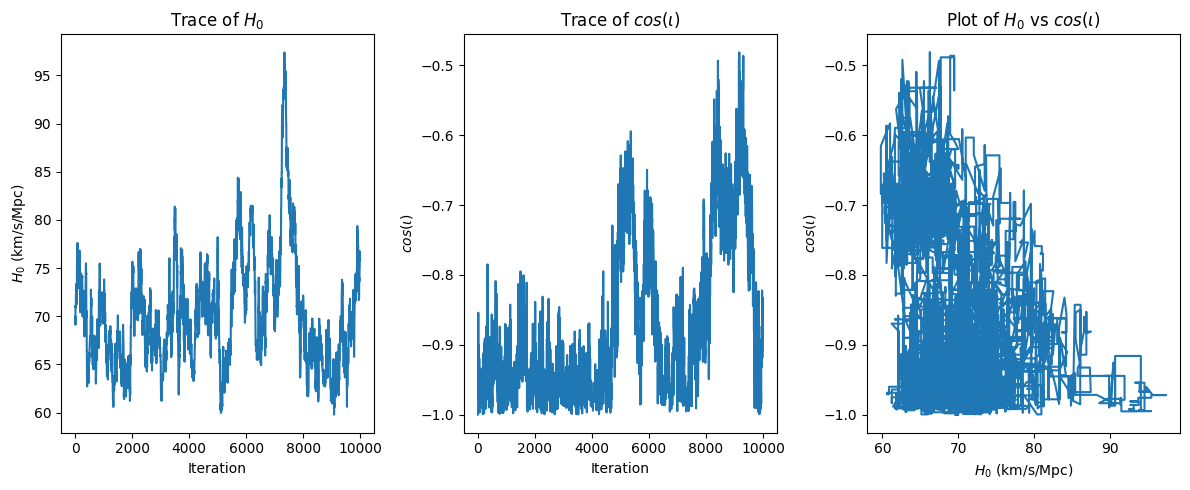

For a H_0 proposal width of 5 and a cos(iota) proposal width of 0.1, the acceptance rate is: 0.2552


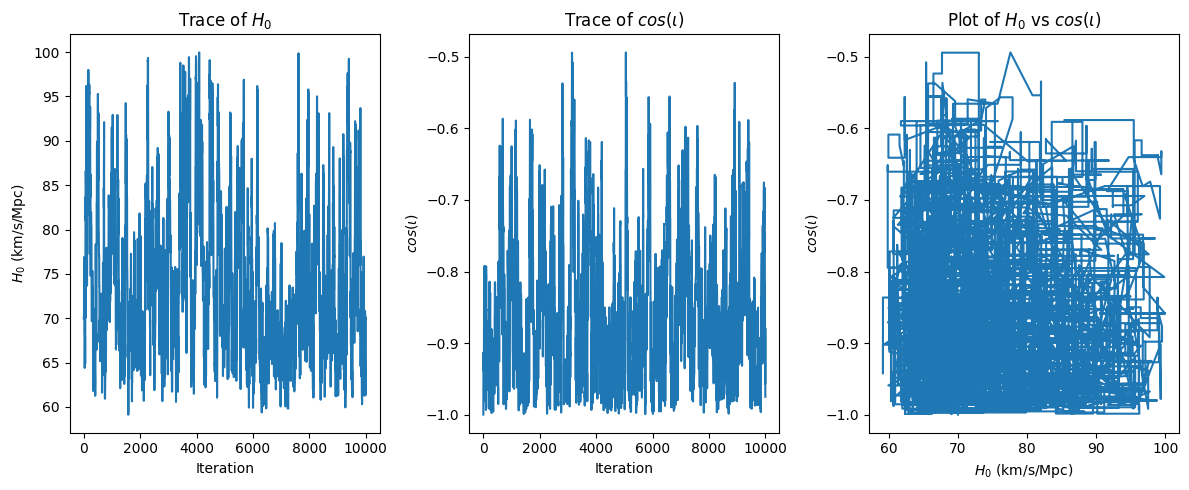

For a H_0 proposal width of 10 and a cos(iota) proposal width of 0.1, the acceptance rate is: 0.1848


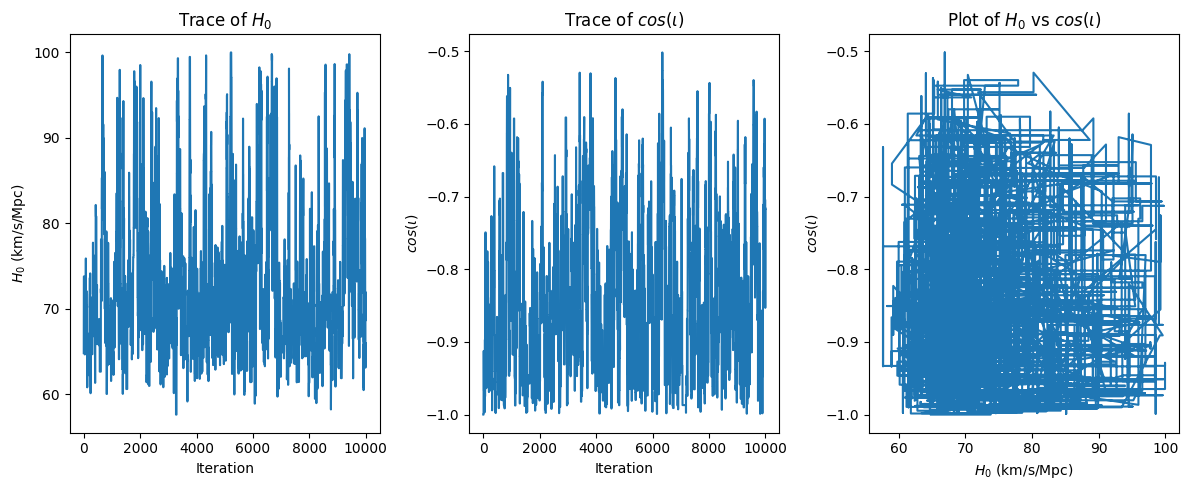

For a H_0 proposal width of 1 and a cos(iota) proposal width of 0.5, the acceptance rate is: 0.0658


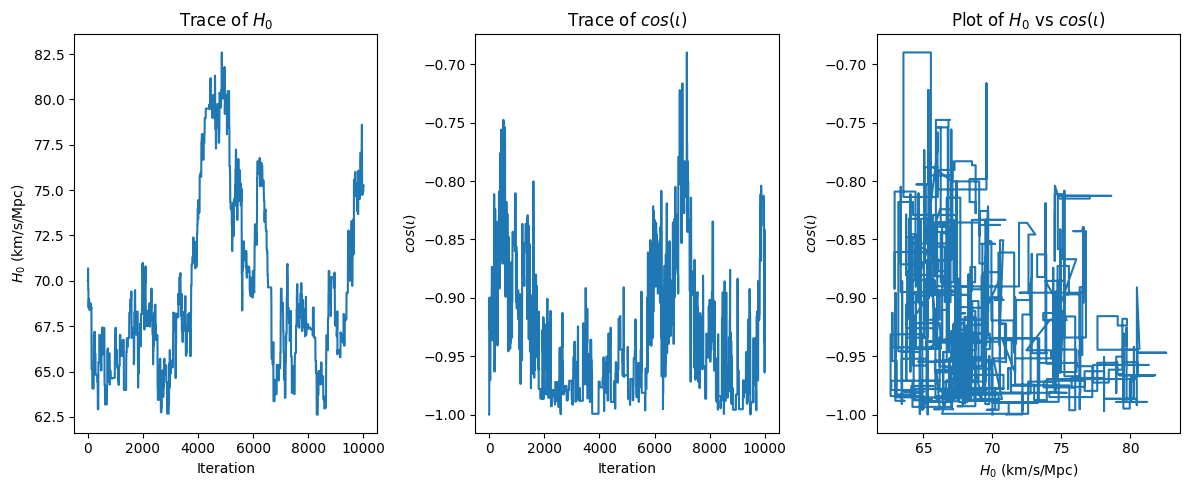

For a H_0 proposal width of 5 and a cos(iota) proposal width of 0.5, the acceptance rate is: 0.0597


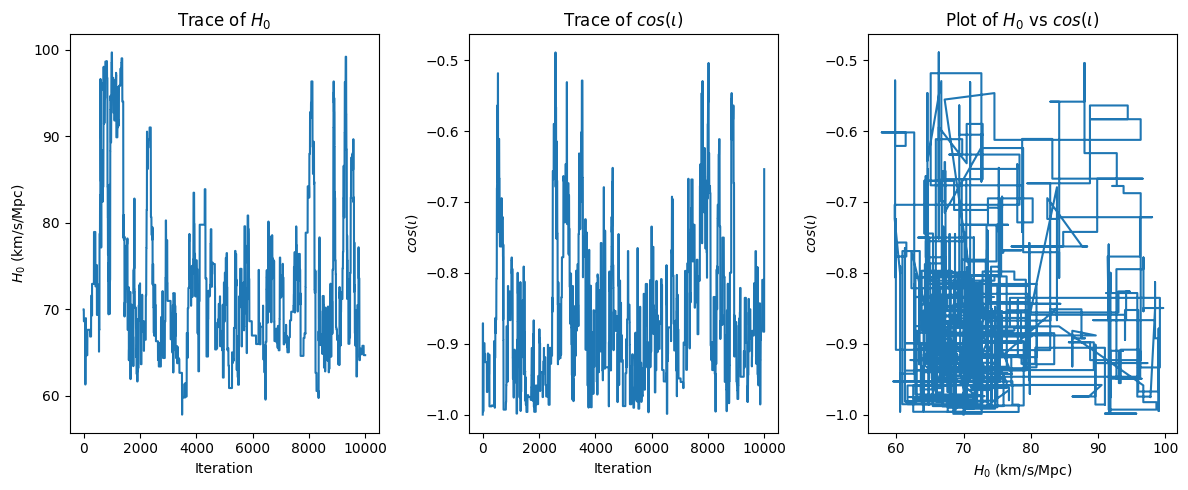

For a H_0 proposal width of 10 and a cos(iota) proposal width of 0.5, the acceptance rate is: 0.0505


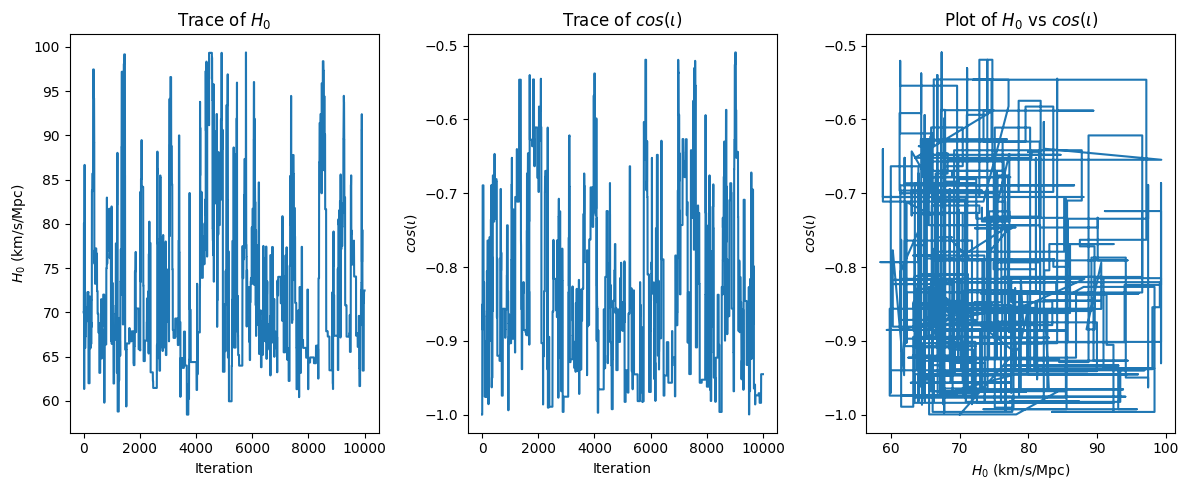

For a H_0 proposal width of 1 and a cos(iota) proposal width of 1, the acceptance rate is: 0.0431


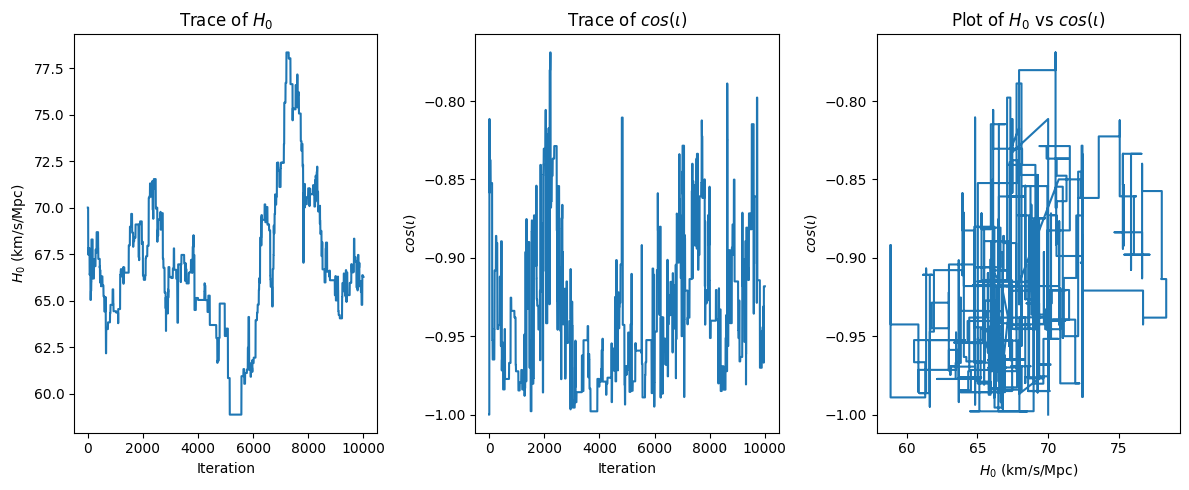

For a H_0 proposal width of 5 and a cos(iota) proposal width of 1, the acceptance rate is: 0.0315


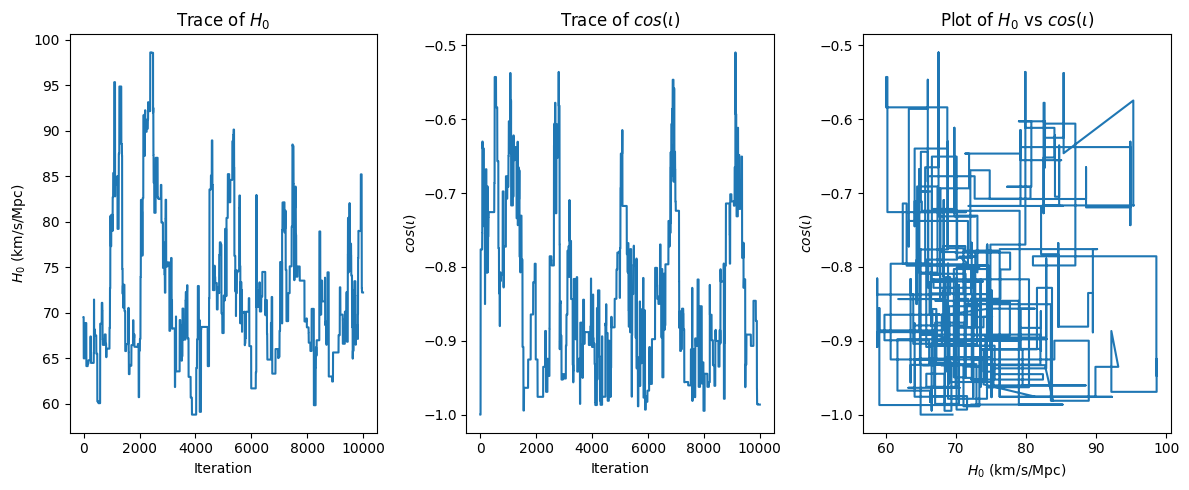

For a H_0 proposal width of 10 and a cos(iota) proposal width of 1, the acceptance rate is: 0.0255


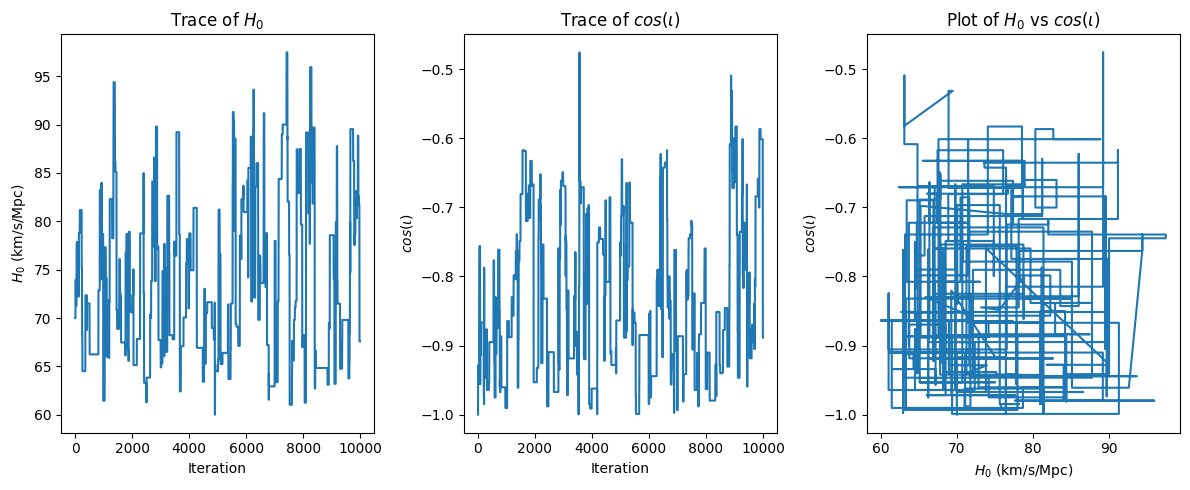

In [13]:
# determine appropriate proposal width by looking at the acceptance rate.
# np.random.seed(30)
n_samples=10000
initial=[70, -1]
proposal_widths_H_0 = [1,5,10]
proposal_widths_c_i = [0.1,0.5,1]

proposal_widths= []
for i in proposal_widths_c_i:
    for j in proposal_widths_H_0:
        proposal_widths.append([j,i])

for proposal_width in proposal_widths:
    acceptance_rate = sampler_2D(n_samples, initial, proposal_width)[3]
    if acceptance_rate != False:
        print(f"For a H_0 proposal width of {proposal_width[0]} and a cos(iota) proposal width of {proposal_width[1]}, the acceptance rate is: {acceptance_rate}")
        accepted_H_0 = sampler_2D(n_samples, initial, proposal_width)[1]

        accepted_cos_iota = sampler_2D(n_samples, initial, proposal_width)[2]

        fig, ax = plt.subplots(1, 3, figsize=(12, 5))
        ax[0].plot(accepted_H_0)
        ax[0].set_title(r"Trace of $H_0$")
        ax[0].set_xlabel("Iteration")
        ax[0].set_ylabel(r"$H_0$ (km/s/Mpc)")
        ax[1].plot(accepted_cos_iota)
        ax[1].set_title(r"Trace of $cos(\iota)$")
        ax[1].set_xlabel("Iteration")
        ax[1].set_ylabel(r"$cos(\iota)$")
        ax[2].plot(accepted_H_0, accepted_cos_iota, '-')
        ax[2].set_title(r"Plot of $H_0$ vs $cos(\iota)$")
        ax[2].set_xlabel(r"$H_0$ (km/s/Mpc)")
        ax[2].set_ylabel(r"$cos(\iota)$")
        plt.tight_layout()
        plt.show()


In [14]:
# https://research-portal.uu.nl/ws/portalfiles/portal/248573031/PhysRevD.110.083033.pdf proposal width of 20%
proposal_width = [5, 0.1]

chains = [sampler_2D(n_samples,initial,proposal_width,likelihood)[0] for likelihood in likelihoods]

# Remove burn-in
burnin = 100
samples = [chain[burnin:]for chain in chains]

H0_samples = [sample[:,0] for sample in samples]

MAPs = []
lows = []
highs = []

for H0_sample in H0_samples:

    # get MAP from KDE
    kde_1d = gaussian_kde(H0_sample)
    H0_grid = np.linspace(min(H0_sample), max(H0_sample), 1000)
    posterior_vals = kde_1d(H0_grid)

    MAP = H0_grid[np.argmax(posterior_vals)]
    MAPs.append(MAP)

    # get credible region
    low, high = compute_hpd(H0_sample)
    lows.append(low)
    highs.append(high)


print(MAPs)
for i in range(len(kde_bandwidths)):
    print(f"For a KDE bandwidth {kde_bandwidths[i]} of H0 = {MAPs[i]} (+{highs[i] - MAPs[i]}, -{MAPs[i] - lows[i]})")

[np.float64(66.65984235324737), np.float64(69.2942038691307), np.float64(64.47459998107533)]
For a KDE bandwidth 0.1 of H0 = 66.65984235324737 (+7.6346500945126365, -4.562901929114666)
For a KDE bandwidth 1 of H0 = 69.2942038691307 (+12.960123200786256, -5.663843312355638)
For a KDE bandwidth 10 of H0 = 64.47459998107533 (+19.925877130792202, -6.833303696735122)


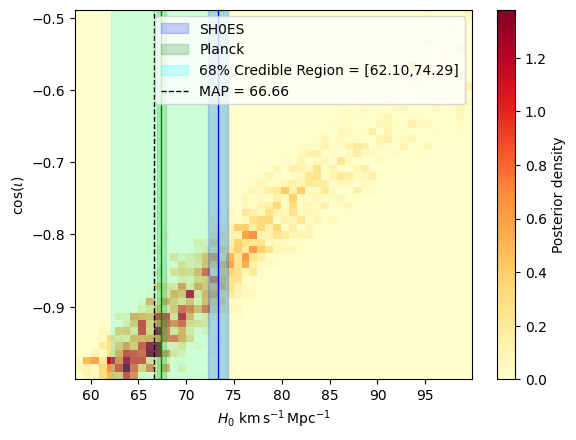

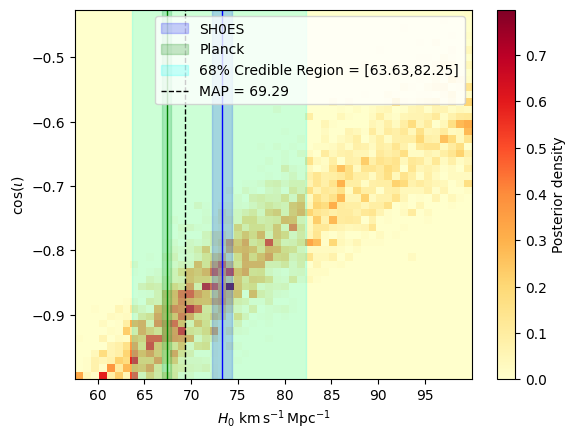

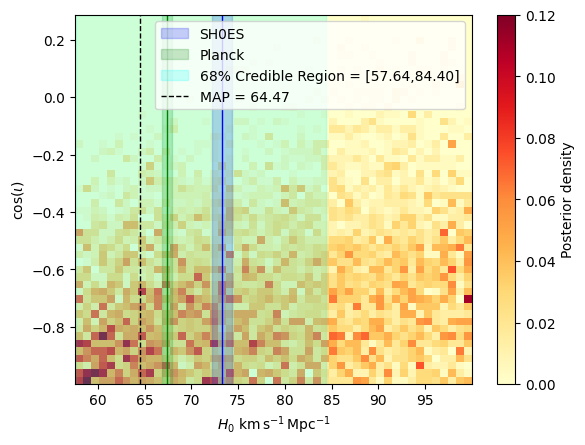

In [16]:
for i in range(len(kde_bandwidths)):
    plt.hist2d(samples[i][:, 0], samples[i][:, 1], bins=50, density=True,cmap='YlOrRd')
    plt.xlabel(r"$H_0 \ \mathrm{{km\,s^{{-1}}\,Mpc^{{-1}}}}$")
    plt.ylabel(r"cos($\iota$)")
    plt.colorbar(label="Posterior density")

    plt.axvspan(
        shoes_mean - shoes_sigma,
        shoes_mean + shoes_sigma,
        color='blue',
        alpha=0.2,
        label='SH0ES'
    )
    plt.axvline(shoes_mean, color='blue', linewidth=1)

    plt.axvspan(
        planck_mean - planck_sigma,
        planck_mean + planck_sigma,
        color='green',
        alpha=0.2,
        label='Planck'
    )
    plt.axvline(planck_mean, color='green', linewidth=1)

    plt.axvspan(
        lows[i],
        highs[i],
        color='cyan',
        alpha=0.2,
        label=f'68% Credible Region = [{lows[i]:.2f},{highs[i]:.2f}]'
    )
    plt.axvline(MAPs[i], color='black',linestyle='--', linewidth=1,label=rf"MAP = {MAPs[i]:.2f}")

    plt.legend()
    plt.show()

# [emcee](#emcee)

As a final measure, we want to visualize how our results change if we use an existing MCMC python package like `emcee` instead of our in-house single chain MCMC. We do this only for our first likelihood surface by default. The walkers are initialized randomly close to and around the same initial parameters we used previously. 

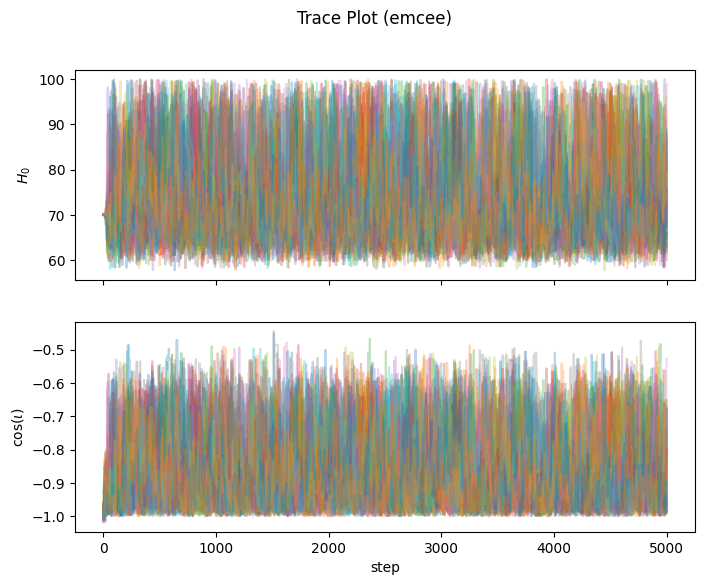

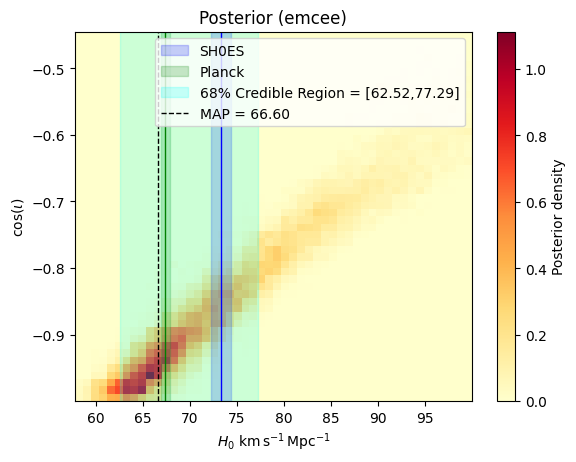

H0 (MAP) = 66.60 (+10.69, -4.08)
Mean acceptance fraction: 0.63581875


In [18]:
def log_posterior(theta):
    return log_prior(theta) + log_likelihood(theta)

ndim = 2
nwalkers = 32
nsteps = 5000

# initialize walkers with small scatter
pos = initial + 1e-2 * np.random.randn(nwalkers, ndim)

# --- run emcee ---
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(pos, nsteps, progress=True)


burnin = 500
samples = sampler.get_chain(discard=burnin, flat=True)

H0_samples = samples[:, 0]



kde_1d = gaussian_kde(H0_samples)
H0_grid = np.linspace(min(H0_samples), max(H0_samples), 1000)
posterior_vals = kde_1d(H0_grid)
MAP = H0_grid[np.argmax(posterior_vals)]


low, high = compute_hpd(H0_samples)

# trace plot
chain = sampler.get_chain()

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(chain[:, :, 0], alpha=0.3)
axes[0].set_ylabel(r"$H_0$")

axes[1].plot(chain[:, :, 1], alpha=0.3)
axes[1].set_ylabel(r"$\cos(\iota)$")
axes[1].set_xlabel("step")

plt.suptitle("Trace Plot (emcee)")
plt.show()


# Main posterior plot
plt.hist2d(samples[:, 0], samples[:, 1], bins=50, density=True, cmap='YlOrRd')

plt.xlabel(r"$H_0 \ \mathrm{{km\,s^{{-1}}\,Mpc^{{-1}}}}$")
plt.ylabel(r"$\cos(\iota)$")
plt.colorbar(label="Posterior density")

plt.axvspan(
    shoes_mean - shoes_sigma,
    shoes_mean + shoes_sigma,
    color='blue',
    alpha=0.2,
    label='SH0ES'
)
plt.axvline(shoes_mean, color='blue', linewidth=1)

plt.axvspan(
    planck_mean - planck_sigma,
    planck_mean + planck_sigma,
    color='green',
    alpha=0.2,
    label='Planck'
)
plt.axvline(planck_mean, color='green', linewidth=1)

plt.axvspan(
    low,
    high,
    color='cyan',
    alpha=0.2,
    label=f'68% Credible Region = [{low:.2f},{high:.2f}]'
)
plt.axvline(MAP, color='black',linestyle='--', linewidth=1,label=rf"MAP = {MAP:.2f}")


plt.legend()
plt.title("Posterior (emcee)")
plt.show()

# --- print result ---
print(f"H0 (MAP) = {MAP:.2f} (+{high - MAP:.2f}, -{MAP - low:.2f})")

# --- acceptance check ---
print("Mean acceptance fraction:", np.mean(sampler.acceptance_fraction))